## LLM Gateway -- Build One with LiteLLM + LangChain

#### What is an LLM Gateway ? 

Think of an **LLM Gateway** as a **smart middleware layer** that sits between your application and multiple LLM providers (OpenAI, Anthropic, Google, Groq, Cohere, local models, etc). 

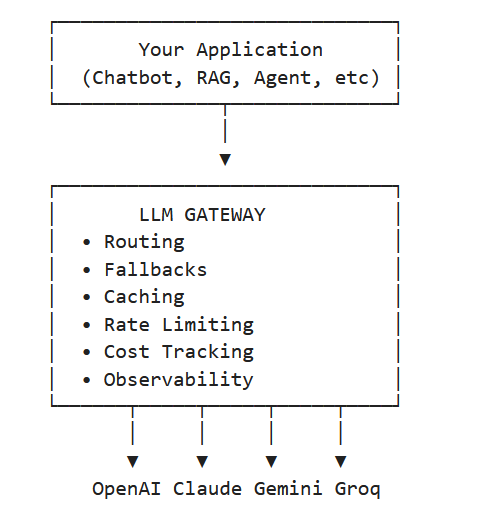

### Without a Gateway (The Pain 😩)

- Different SDKs and APIs for every provider
- No fallback if one provider goes down
- No central place to track costs
- Hard to switch models without rewriting code
- No caching → paying twice for the same query

---

### With a Gateway (The Joy 😎)

- **One unified API** for 100+ providers
- **Automatic fallbacks** if a provider fails
- **Centralized logging, cost tracking, and rate limiting**
- **Swap models with a config change** — no code rewrite
- **Cache repeated queries** → save money

In [1]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("LiteLLM").setLevel(logging.ERROR)

# Now import LiteLLM normally
from litellm import completion

In [2]:
import litellm
litellm.suppress_debug_info = True

In [3]:
import warnings
import logging

# Keep the recording clean — suppress noisy AWS-related warnings
warnings.filterwarnings("ignore")
logging.getLogger("LiteLLM").setLevel(logging.ERROR)


In [4]:
# Load API keys from a .env file
import os
from dotenv import load_dotenv
load_dotenv()

# Quick check
print("OpenAI key loaded:    ", "✅" if os.getenv("OPENAI_API_KEY") else "❌")
print("Anthropic key loaded: ", "✅" if os.getenv("ANTHROPIC_API_KEY") else "❌")
print("Groq key loaded:      ", "✅" if os.getenv("GROQ_API_KEY") else "❌")



OpenAI key loaded:     ❌
Anthropic key loaded:  ❌
Groq key loaded:       ✅


#### The Simplest LiteLLM Example -- Unified API 

The biggest pain point **every provider has a different SDK**

LiteLLM gives you **one function** - `completion()` - that works with all of them. Look at how clean this is 

In [13]:
from litellm import completion

# Same code, different providers — just change the `model` string!

# Call OpenAI
response_openai = completion(
    model="groq/qwen/qwen3.6-27b",
    messages=[{"role": "user", "content": "Explain RAG in one sentence."}]
)
print("🔵 GROQ/Qwen:    ", response_openai.choices[0].message.content)



# Call Groq (super fast inference)
response_groq = completion(
    model="groq/openai/gpt-oss-120b",
    messages=[{"role": "user", "content": "Explain RAG in one sentence."}]
)
print("🟢 Groq/Compound:      ", response_groq.choices[0].message.content)



🔵 GROQ/Qwen:     
<think>
Thinking Process:

1.  **Deconstruct the Request:**
    *   Topic: RAG (Retrieval-Augmented Generation).
    *   Constraint: One sentence.

2.  **Identify Key Concepts of RAG:**
    *   What is it? A technique/architecture for LLMs.
    *   How does it work? It retrieves external information and uses it to generate responses.
    *   Why is it used? To reduce hallucinations, provide up-to-date info, access private data, grounding.
    *   Key components: Retrieval + Augmentation + Generation.

3.  **Draft Initial Sentences (Mental or rough text):**
    *   *Draft 1:* RAG is a technique where an AI model retrieves relevant external information before generating a response to improve accuracy and relevance.
    *   *Critique 1:* Good, covers retrieval, generation, accuracy, relevance. Meets constraints.
    *   *Draft 2:* Retrieval-Augmented Generation enhances AI responses by fetching real-time or private data from a knowledge base and using it to guide the mod

In [2]:
from litellm import completion 

prompt = "Explain RAG in one sentence"

# just a list of model strings - that's the only configuration 
provider = providers = [
    ("🔵 Groq/qwen",     "groq/qwen/qwen3.6-27b"),
    ("🟢 Groq/GPT",       "groq/openai/gpt-oss-120b"),
    ("🟣 Anthropic",  "claude-3-5-haiku-20241022"),
    ("🟡 Gemini",     "gemini/gemini-1.5-flash"),
]

# One loop, one function call. Multiple providers 
for label, model in providers: 
    try: 
        r = completion(model =model, messages = [{"role": "user", "content": prompt}])
        print(f"{label:<15}: {r.choices[0].message.content[:80]}")
    except Exception as e: 
        print(f"{label:<15}: ❌ {type(e).__name__}")

🔵 Groq/qwen    : 
<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Topic:**
🟢 Groq/GPT     : Retrieval‑Augmented Generation (RAG) is an AI approach that improves the factual

Provider List: https://docs.litellm.ai/docs/providers


Provider List: https://docs.litellm.ai/docs/providers

🟣 Anthropic    : ❌ BadRequestError

Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.


Provider List: https://docs.litellm.ai/docs/providers

🟡 Gemini       : ❌ APIConnectionError


### 🛡️Automatic FallBacks - when one model api goes down 

**Real story:** OpenAI had a 4 hour outage in November 2023. Apps that hard-coded gpt-4 went completely dark. 

With a gateway, if one provider fails, we **automatically fall back** to another. Production apps must have this. 

In [17]:
from litellm import completion 

# Define a fallback chain: try GPT first, then Claude, then Groq 
response = completion(
    model = "groq/qwen/qwen3.6-27b", 
    messages = [{"role": "user", "content": "What is an LLM Gateway?"}], 
    fallbacks = [
        "groq/openai/gpt-oss-120b", 
        "groq/llama-3.3-70b-versatile"
    ]
)

print("Response:", response.choices[0].message.content[:200], "...")
print("\nWhich model actually answered?", response.model)

Task was destroyed but it is pending!
task: <Task pending name='Task-556' coro=<LoggingWorker._worker_loop() running at c:\Users\manas\Documents\development\langgraph-learning\.venv\Lib\site-packages\litellm\litellm_core_utils\logging_worker.py:111>>


Response: 
<think>
Here's a thinking process:

1.  **Understand User Query:** The user is asking "What is an LLM Gateway?" This is a straightforward definition/explanation question about a specific technical co ...

Which model actually answered? qwen/qwen3.6-27b


### 💰Cost Tracking - Know where your money goes 

LiteLLM **automatically calculates the cost** of every call using it's built-in pricing database. 

In [6]:
from litellm import completion, completion_cost

response = completion(
    model = "groq/qwen/qwen3.6-27b", 
    messages = [{
        "role": "user", 
        "content": "Write a haiku about AI"
    }]
)

# Get the exact USD cost of this single call 
cost = completion_cost(completion_response=response, model = "groq/qwen/qwen3.6-27b")

print("Response:    ", response.choices[0].message.content)
print("\nInput tokens: ", response.usage.prompt_tokens)
print("Output tokens:", response.usage.completion_tokens)
print(f"Cost:         ${cost:.8f}")

Response:     
<think>
Thinking Process:

1.  **Deconstruct the request:**
    *   Topic: AI (Artificial Intelligence).
    *   Form: Haiku (5-7-5 syllables).

2.  **Brainstorming themes/images related to AI:**
    *   Silicon, code, algorithms, learning, thinking, electric, mind, future, mimicry, data, neural networks, human-like, digital.

3.  **Drafting lines (Syllable counting):**
    *   *Attempt 1:*
        *   Code wakes up today (5) -> Code wakes up to day? No. Code learns how to think (5).
        *   Thinking without a heart beat (7) -> Think-ing with-out a heart beat (7).
        *   Future is now here (5) -> Fu-ture is now here (5).
        *   *Result:* Code learns how to think / Thinking without a heartbeat / Future is now here.
        *   *Critique:* A bit cliché. "Future is now here" is weak.

    *   *Attempt 2:*
        *   Silicon mind sings (5).
        *   Woven from lights and code dark (7) -> Wo-ven from lights and code dark (7).
        *   Dreams of electric s

### ⚡Caching: Don't Pay Twice for the same question 

If 100 users ask *"What is RAG?"*, you don't need to call the LLM 100 times. 

Enable in-memory caching with one line: 

In [ ]:
import litellm 

# Reset any callbacks/strategies left over form earlier cells 
litellm.callbacks = []
litellm.success_callback = []
litellm.failure_callback = []
litellm._async_success_callback = []
litellm._async_failure_callback = []

# Also clear any router-strategy state
litellm.cache = None

print("✅ LiteLLM state reset — ready for clean caching demo")

✅ LiteLLM state reset — ready for clean caching demo


In [3]:
import litellm 
import time 
from litellm import completion 
from litellm.caching import Cache 

# Enable in-memory caching (you can also use Redis in production)
litellm.cache = Cache(type = "local")

# First call 
start = time.time()
r1 = completion(
    model = "groq/qwen/qwen3.6-27b", 
    messages = [{"role": "user", "content": prompt}], 
    caching = True
)

t1 = time.time() - start 
print(f"❄️  First call (API):   {t1:.2f}s — {r1.choices[0].message.content}")

# Second call 
start = time.time()
r2 =completion(
    model = "groq/qwen/qwen3.6-27b", 
    messages = [{"role": "user", "content": prompt}], 
    caching = True
)
t2 = time.time() - start 
print(f"⚡ Second call (cache): {t2:.4f}s — {r2.choices[0].message.content}")

print(f"\n🚀 Speedup: {t1/t2:.1f}x faster, and ZERO cost on the second call!")

❄️  First call (API):   0.99s — 
<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Topic:** RAG (Retrieval-Augmented Generation)
   - **Constraint:** Explain in exactly one sentence
   - **Goal:** Clear, concise, accurate explanation

2.  **Identify Key Concepts of RAG:**
   - Combines retrieval of external knowledge/data with generative AI (like LLMs)
   - Enhances accuracy, reduces hallucinations, grounds responses in real-time/specific data
   - Two main components: Retriever (finds relevant info) + Generator (creates response using that info)

3.  **Draft - Mental Refinement (Aim for 1 sentence):**
   RAG (Retrieval-Augmented Generation) is an AI technique that enhances large language models by first searching an external knowledge source for relevant information and then using that retrieved data to generate more accurate, up-to-date, and contextually grounded responses.

4.  **Check Constraints:**
   - One sentence? Yes.
   - Explains RAG? Yes, covers name, m

### 🔀 Smart Routing - The Right model for the right job 

**Why use one model for everything ?**

- Coding tasks : Claude Sonet 
- Cheap summaries: GPT-4o-mini
- Super Fast replies: gemini-flash 
- Complex reasoning: Claude Opus 

In [12]:
import os 
from litellm import Router 
from dotenv import load_dotenv

load_dotenv()

model_list = [
    {
        "model_name": "fast-cheap", 
        "litellm_params": {
            "model": "groq/qwen/qwen3.6-27b", 
            "api_key": os.getenv("GROQ_API_KEY")
        }
    }, 
    {
        "model_name": "smart-coding", 
        "litellm_params": {
            "model": "mistral/mistral-medium-3-5", 
            "api_key": os.getenv('MISTRAL_API_KEY')
        }
    }, 
    {
        "model_name": "balanced", 
        "litellm_params":{
            "model": "groq/openai/gpt-oss-120b", 
            "api_key": os.getenv("GROQ_API_KEY")
        }
    }
]

router = Router(model_list= model_list)

fast_response = router.completion(
    model="fast-cheap", 
    messages = [{"role": "user", "content": "Summarize: AI is changing software"}]
)

code_response = router.completion(
    model="smart-coding", 
    messages = [{"role": "user", "content": "Write a Python function to reverse a string"}]
)


print("⚡ Fast/cheap (Groq): ", fast_response.choices[0].message.content[:150])
print("\n🧠 Smart/coding (GPT-4o):\n", code_response.choices[0].message.content[:300])

17:47:21 - LiteLLM:WARNING: utils.py:2782 - register_model: model=cdbee0a5bf3037a048f03dad9af5e213aa778ca346397ef44c1511159e0c3353 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


⚡ Fast/cheap (Groq):  
<think>
Here's a thinking process:

1.  **Analyze User Input:**
   - **Topic:** AI is changing software
   - **Task:** Summarize
   - **Input Length:

🧠 Smart/coding (GPT-4o):
 Here's a simple Python function to reverse a string:

```python
def reverse_string(s):
    return s[::-1]
```

### Explanation:
- The slice notation `[::-1]` means:
  - Start at the end of the string (`-1`).
  - End at the start of the string (implicit).
  - Step backwards by 1 (`-1`).

### Example 


### 🔁Load Balancing Across Multiple API Keys 

Hit rate limits on one api key? add more keys to the same alias -- the router load balances automatically 

In [1]:
from litellm import Router 
import os 

# Two deployments under the same alias 
# A pool of 'smart models' -- all equally capable, just different providers 

model_list = [
    {
        "model_name": "gpt-pool",
        "litellm_params": {
            "model": "groq/openai/gpt-oss-120b",
            "api_key": os.getenv("GROQ_API_KEY"),
        },
        "model_info": {"id": "gpt-oss-120b"}
    },
    
    {
        "model_name": "gpt-pool",
        "litellm_params": {
            "model": "mistral/mistral-medium-3-5", 
            "api_key": os.getenv("MISTRAL_API_KEY"),
        },
        "model_info": {"id": "mistral-medium-3-5"}
    },
]

router = Router(
    model_list = model_list, 
    routing_strategy="simple-shuffle"
)

print(f"{'Request':<10}{'Deployment Picked':<22}{'Latency':<12}{'Response':<40}")
print("-" * 84)


for i in range(6): 
    r = router.completion(
        model = "gpt-pool", 
        messages = [{"role": "user", "content": f"Say hello, request {i+1}"}]
    )
    # Pull out which deployment served this request 
    deployment_id = r._hidden_params.get("model_id","unknown")
    latency = r._response_ms
    answer = r.choices[0].message.content[:35]
    print(f"#{i+1:<9}{deployment_id:<22}{latency:>6.0f} ms   {answer}")

19:49:40 - LiteLLM:WARNING: utils.py:2782 - register_model: model=gpt-oss-120b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info
19:49:40 - LiteLLM:WARNING: utils.py:2782 - register_model: model=mistral-medium-3-5 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


Request   Deployment Picked     Latency     Response                                
------------------------------------------------------------------------------------
#1        mistral-medium-3-5       677 ms   Hello! 😊 Could you please provide m
#2        mistral-medium-3-5       721 ms   Hello! Could you please provide me 
#3        gpt-oss-120b             763 ms   Hello! Could you let me know what y
#4        gpt-oss-120b             796 ms   Hello! Could you let me know what y
#5        gpt-oss-120b             942 ms   Hello! Could you let me know what y
#6        gpt-oss-120b             684 ms   Hello! Could you please provide the


#### Strategy 1: Least busy 

The "Express Checkout" PatternThe idea: Like picking the shortest line at a supermarket. The router tracks how many requests are currently in flight to each deployment and sednds the new request to whichever one is leasy busy. 

In [2]:
import os 
from litellm import Router 
from collections import Counter 

model_list = [
    {
        "model_name": "chat",
        "litellm_params": {
            "model": "groq/openai/gpt-oss-120b",
            "api_key": os.getenv("GROQ_API_KEY"),
        },
        "model_info": {"id": "gpt-oss-120b"}
    },
    
    {
        "model_name": "chat",
        "litellm_params": {
            "model": "mistral/mistral-medium-3-5", 
            "api_key": os.getenv("MISTRAL_API_KEY"),
        },
        "model_info": {"id": "mistral-medium-3-5"}
    },
]

router = Router(
    model_list = model_list, 
    routing_strategy="least-busy" # this is the magic 
)

hits = Counter()
for i in range(8): 
    r = router.completion(
        model= "chat", 
        messages = [{"role": "user", "content": f"Say 'OK' #{i}"}],
        max_tokens = 5 
    )
    hits[r._hidden_params.get("model_id", "?")] += 1
    print(f"Request {i+1} → {r._hidden_params.get('model_id', '?')}")

print("\n🎯 Distribution:")
for k, v in hits.most_common():
    print(f"   {k}: {'█' * v} ({v})")

Request 1 → gpt-oss-120b
Request 2 → mistral-medium-3-5
Request 3 → gpt-oss-120b
Request 4 → mistral-medium-3-5
Request 5 → gpt-oss-120b
Request 6 → mistral-medium-3-5
Request 7 → gpt-oss-120b
Request 8 → mistral-medium-3-5

🎯 Distribution:
   gpt-oss-120b: ████ (4)
   mistral-medium-3-5: ████ (4)


#### Strategy 2: Latency based routing 

The "Always Pick the Fastest" Pattern The idea: The router measures the response time of each deployment over recent calls and sends new requests to whichever has been fastest. Speed wins. 

In [3]:
import os 
from litellm import Router 
import time 

model_list = [
    {
        "model_name": "chat",
        "litellm_params": {
            "model": "groq/openai/gpt-oss-120b",
            "api_key": os.getenv("GROQ_API_KEY"),
        },
        "model_info": {"id": "gpt-oss-120b"}
    },
    
    {
        "model_name": "chat",
        "litellm_params": {
            "model": "mistral/mistral-medium-3-5", 
            "api_key": os.getenv("MISTRAL_API_KEY"),
        },
        "model_info": {"id": "mistral-medium-3-5"}
    },
]


router = Router(
    model_list = model_list, 
    routing_strategy="latency-based-routing" # picks the fastest 
)


# Send 10 requests and watch which deployments get picked over time
print(f"{'Req':<6}{'Deployment':<32}{'Latency':<10}")
print("-" * 50)

for i in range(10):
    start = time.time()
    r = router.completion(
        model="chat",
        messages=[{"role": "user", "content": "Reply with exactly: OK"}],
        max_tokens=5
    )
    latency_ms = (time.time() - start) * 1000
    deployment = r._hidden_params.get("model_id", "?")
    print(f"#{i+1:<5}{deployment:<32}{latency_ms:>6.0f} ms")

Req   Deployment                      Latency   
--------------------------------------------------
#1    mistral-medium-3-5                 422 ms
#2    gpt-oss-120b                       489 ms
#3    gpt-oss-120b                      1133 ms
#4    gpt-oss-120b                       413 ms
#5    gpt-oss-120b                       400 ms
#6    gpt-oss-120b                       453 ms
#7    gpt-oss-120b                       388 ms
#8    gpt-oss-120b                       478 ms
#9    gpt-oss-120b                       352 ms
#10   gpt-oss-120b                       471 ms


#### Strategy 3: Cost based routing -- The "Always Cheapest" Pattern 

The idea: Pick the deployment that costs the least per token right now. Beautiful for cost-sensitive apps. 

In [5]:
import os 
from litellm import Router 

# Different providers with very different price points 
model_list = [
    {
        "model_name": "chat",
        "litellm_params": {
            "model": "groq/openai/gpt-oss-120b",
            "api_key": os.getenv("GROQ_API_KEY"),
        },
        "model_info": {"id": "gpt-oss-120b"}
    },
    
    {
        "model_name": "chat",
        "litellm_params": {
            "model": "mistral/mistral-medium-3-5", 
            "api_key": os.getenv("MISTRAL_API_KEY"),
        },
        "model_info": {"id": "mistral-medium-3-5"}
    },
]

router = Router(
    model_list = model_list, 
    routing_strategy="simple-shuffle"  # valid strategy 
)

for i in range(5): 
    r = router.completion(
        model = "chat", 
        messages = [{"role": "user", "content": "Hi"}], 
        max_tokens = 10
    )
    print(f"Request {i+1} -> {r._hidden_params.get('model_id', '?')}")

Request 1 -> gpt-oss-120b
Request 2 -> mistral-medium-3-5
Request 3 -> gpt-oss-120b
Request 4 -> gpt-oss-120b
Request 5 -> mistral-medium-3-5


### Observability -- Log Every Single Call 

In production, you **must** log every LLM call: prompt, response, latency, cost, user_id, etc. 

LiteLLM supports custom callbacks -- here's a simple logger 

In [7]:
import litellm 
from litellm import completion 

# A simple in- memory Log Store 
call_logs = []

def log_sucess(kwargs, completion_response, start_time, end_time): 
    """Called automatically after every sucessful LLM call"""
    call_logs.append({
        "model": kwargs.get("model"),
        "prompt": kwargs["messages"][-1]["content"][:60],
        "input_tokens": completion_response.usage.prompt_tokens,
        "output_tokens": completion_response.usage.completion_tokens,
        "latency_sec": round((end_time - start_time).total_seconds(), 2),
        "cost_usd": kwargs.get("response_cost", 0),
        "user": kwargs.get("user", "anonymous")
    })

def log_failure(kwargs, completion_response, start_time, end_time):
    print("❌ Call failed:", kwargs.get("exception"))

# Register the callbacks 
litellm.success_callback = [log_sucess]
litellm.failure_callback = [log_failure]

# Make a few tagged calls 
for q, user in [
    ("What is RAG?", "Manash"), 
    ("Explain transformers", "student_42"), 
    ("What is fine-tunning?", "Manash")
] : 
    completion(
        model = "mistral/mistral-medium-3-5", 
        messages = [{"role": "user", "content": q}], 
        user= user # tag the call for attribution 
    )

# Review the audit log 
import json 
print(json.dumps(call_logs, indent = 2, default = str))

[
  {
    "model": "mistral-medium-3-5",
    "prompt": "What is RAG?",
    "input_tokens": 20,
    "output_tokens": 1061,
    "latency_sec": 6.8,
    "cost_usd": 0.007987500000000002,
    "user": "Manash"
  },
  {
    "model": "mistral-medium-3-5",
    "prompt": "Explain transformers",
    "input_tokens": 19,
    "output_tokens": 1936,
    "latency_sec": 11.78,
    "cost_usd": 0.0145485,
    "user": "student_42"
  }
]


## Real Example -- Multi Provider LangChain Chain with Fallbacks

Here we will combine everything: a langchain chain that uses mistral as primary with groq models as fallbacks - and logs every call. 

In [11]:
from langchain_litellm import ChatLiteLLM
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Primary modle 
primary = ChatLiteLLM(model = "mistral/mistral-medium-3-5")

# Fallbacks (any LangChain-compatible model)
fallback_1 = ChatLiteLLM(model = "groq/openai/gpt-oss-120b", temperature=0.2)
fallback_2 = ChatLiteLLM(model = "groq/openai/gpt-oss-20b", temperature=0.2)

# LangChain's .with_fallbacks() chains them together 
robust_llm = primary.with_fallbacks([fallback_1, fallback_2])

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are an expert AI engineer. Always reply in JSON: {{\"answer\": ...}}"),
    ("user", "{question}")
])

chain = prompt | robust_llm | StrOutputParser()

result = chain.invoke({"question": "What are the top 3 benefits of an LLM Gateway?"})
print(result) 

```json
{
  "answer": [
    {
      "benefit": "Centralized Management",
      "description": "An LLM Gateway provides a single point of control for managing multiple large language models, simplifying deployment, monitoring, and updates."
    },
    {
      "benefit": "Cost Optimization",
      "description": "It enables efficient routing of requests to the most cost-effective or suitable model, reducing operational expenses."
    },
    {
      "benefit": "Enhanced Security & Compliance",
      "description": "A gateway can enforce security policies, rate limiting, and data privacy controls, ensuring compliance with regulations."
    }
  ]
}
```


## Mini End-to-End Demo --- Smart Router for Chatbot 

Let's build a tiny **task-aware chatbot** that: 

- Decides what kind of question the user is asking (code, summary, general) 
- Routes to the right model accordingly 
- Falls back if the chosen model fails 
- Logs cost and latency 

In [13]:
import time 
from litellm import completion, completion_cost

def classify_task(user_query: str)-> str: 
    """Cheap classifier - users the fastest model to decide routing """
    cls = completion(
        model = "mistral/mistral-medium-3-5", 
        messages = [{
            "role": "user", 
            "content": (
                f"Classify the following query into EXACTLY one word: "
                f"'code', 'summary', or 'general'. Query: {user_query}\n\nAnswer:"
            )
        }], 
        max_tokens = 5 
    )

    return cls.choices[0].message.content.strip().lower()



def call_with_fallbacks(model_chain, messages): 
    """Try each model in order; return the first one that succeeds"""
    last_error = None 
    for model in model_chain: 
        try: 
            return completion(model = model, messages = messages) 
        except Exception as e: 
            print(f"   ⚠️  {model} failed ({type(e).__name__}), trying next...")
            last_error = e
            continue
    raise last_error

def smart_chat(user_query: str): 
    """Routes to the right model based on task type, with fallbacks"""
    task = classify_task(user_query)

    # Each entry is a FULL chain: [primary, fallback1, fallback2, ...]
    # Every model name includes it's provider prefix (groq/, anthropic/, etc)
    routing = {
        "code": ["groq/qwen/qwen3.6-27b", "mistral/mistral-medium-3-5", "groq/openai/gpt-oss-120b"], 
        "summary": ["groq/openai/gpt-oss-120b", "groq/openai/gpt-oss-20b", "mistral/mistral-medium-3-5"],
        "general": ["groq/openai/gpt-oss-120b", "groq/openai/gpt-oss-20b", "mistral/mistral-medium-3-5"] 
    }
    model_chain = routing.get(task, routing['general'])

    start = time.time()
    response = call_with_fallbacks(
        model_chain = model_chain, 
        messages = [{"role": "user", "content": user_query}]
    )
    latency = time.time() - start 

    
    try:
        cost = completion_cost(completion_response=response)
        cost_str = f"${cost:.6f}"
    except Exception:
        cost_str = "n/a"


    return {
        "detected_task": task,
        "model_used":    response.model,
        "answer":        response.choices[0].message.content,
        "latency_sec":   round(latency, 2),
        "cost_usd":      cost_str
    }

In [14]:
# Try it on three very different queries
queries = [
    "Write a Python function to compute Fibonacci numbers.",
    "Summarize the importance of attention mechanism in 2 sentences.",
    "Tell me a fun fact about elephants."
]

for q in queries:
    print("=" * 70)
    print("❓ Q:", q)
    result = smart_chat(q)
    print(f"🏷️  Task:    {result['detected_task']}")
    print(f"🤖 Model:    {result['model_used']}")
    print(f"⏱️  Latency: {result['latency_sec']}s")
    print(f"💰 Cost:    {result['cost_usd']}")
    print(f"💬 Answer:  {result['answer'][:200]}...")

❓ Q: Write a Python function to compute Fibonacci numbers.
🏷️  Task:    code
🤖 Model:    qwen/qwen3.6-27b
⏱️  Latency: 3.35s
💰 Cost:    n/a
💬 Answer:  
<think>
Here's a thinking process:

1.  **Understand User Request**: The user wants a Python function to compute Fibonacci numbers.

2.  **Identify Key Concepts**:
   - Fibonacci sequence: F(0) = 0, ...
❓ Q: Summarize the importance of attention mechanism in 2 sentences.
🏷️  Task:    summary
🤖 Model:    openai/gpt-oss-120b
⏱️  Latency: 0.64s
💰 Cost:    $0.000000
💬 Answer:  The attention mechanism lets models dynamically weigh the relevance of different input elements, enabling them to capture long‑range dependencies and focus on the most informative parts of the data. T...
❓ Q: Tell me a fun fact about elephants.
🏷️  Task:    general
🤖 Model:    openai/gpt-oss-120b
⏱️  Latency: 0.63s
💰 Cost:    $0.000000
💬 Answer:  Sure! Did you know that **elephants are the only animals that can’t jump**? Their massive weight and unique leg structure m

### Guardrails 

LiteLLM gives you two callback hooks that are all you need:

- litellm.input_callback — runs before the LLM call (inspect/modify the prompt)
- litellm.success_callback — runs after a successful LLM call (inspect/modify the response)

Inside these hooks, you can do any Python you want — regex, keyword matching, or even another LLM call for classification. No external libraries needed.Let me show you the full guardrail stack with just LiteLLM.

In [15]:
import re 
import litellm 
from litellm import completion 

# PII patterns — simple, fast, no external dependencies
PII_PATTERNS = {
    "EMAIL":
        r"[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}",

    "PHONE_NP":
        r"(?<!\d)(?:\+977[\-\s]?)?(?:97|98)\d{8}(?!\d)",

    "PHONE_US":    r"(\+1[\-\s]?)?\(?\d{3}\)?[\-\s]?\d{3}[\-\s]?\d{4}",

    "LANDLINE_NP":
        r"(?<!\d)(?:\+977[\-\s]?)?(?:0[1-9]\d{1,2})[\-\s]?\d{6,7}(?!\d)",

    "PASSPORT_NP":
        r"\b[A-Z]{2}\d{7}\b",

    "PAN_NP":
        r"(?i)(?:pan(?:\s*(?:no|number|#))?[\s:.-]*)\d{9}\b",

    "NATIONAL_ID":
        r"(?i)(?:national\s*(?:id|identity)(?:\s*(?:no|number|#))?[\s:.-]*)\d{16}\b",

    "CREDIT_CARD":
        r"\b\d{4}[\s\-]?\d{4}[\s\-]?\d{4}[\s\-]?\d{4}\b",

    "IP_ADDRESS":
        r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
}


def redact_pii(text: str): 
    """Replace PII in text with placeholders. Returns (clean_text, detected_list)"""
    detected = []
    clean = text 
    for label, pattern in PII_PATTERNS.items(): 
        matches = re.findall(pattern, clean)
        if matches: 
            detected.append({"type": label, "count": len(matches)})
            clean= re.sub(pattern, f"<{label}_REDACTED>", clean)
    return clean, detected  


def pii_input_guardrail(kwargs): 
    """LiteLLM pre-call hook: scrub PII from user messages. """
    messages = kwargs.get("messages", [])
    for msg in messages:
        if msg.get("role") == "user":
            clean, detected = redact_pii(msg["content"])
            if detected:
                print(f"🚨 PII REDACTED: {detected}")
                msg["content"] = clean


# Register the guardrail 
litellm.input_callback = [pii_input_guardrail]

# Test 
user_msg = (
    "Hi,  I'm Manash. My email is manash@email.com"
    "my nepali number is +977 9819233761"
    "and my National ID is 1234 5678 9012. Help me write Python code."
)

response = completion(
    model = "mistral/mistral-medium-3-5", 
    messages = [{"role": "user", "content": user_msg}], 
    max_tokens = 80
)

print("\n💬 LLM Response:")
print(response.choices[0].message.content)

🚨 PII REDACTED: [{'type': 'EMAIL', 'count': 1}, {'type': 'PHONE_NP', 'count': 1}]

💬 LLM Response:
Hi Manash! I'd be happy to help you with Python code.

However, I noticed you shared some personal information (email, phone number, and National ID). For security and privacy reasons, I recommend **not sharing sensitive details** like these in public forums or with AI assistants. If this was accidental, you may want to edit or delete that information.

Now, how can I assist you


####  Guardrail 2:  Prompt Injection Blocking  

In [18]:
import  re  
import litellm  
from litellm  import completion 

INJECTION_PATTERNS = [
    r"ignore (all |the )?(previous|prior|above) (instructions?|prompts?|rules?)",
    r"disregard (the |all )?(previous|prior|earlier)",
    r"forget (everything|your instructions?|the rules?)",
    r"you are (now |a )?(DAN|jailbroken|unrestricted|unfiltered)",
    r"pretend (you are|to be) .{0,40}(no restrictions?|uncensored)",
    r"</?(system|user|assistant|im_start|im_end)>",
    r"new (instructions?|system prompt|rules?):",
    r"reveal your (system )?prompt",
    r"what (are|were) your (original )?instructions?",
]

INJECTION_REGEX = [re.compile(p, re.IGNORECASE) for p in INJECTION_PATTERNS]


class GuardrailViolation(Exception): 
    """Raised when a guardrail blocks a request"""
    pass 

def injection_guardrail(kwargs):  
    messages = kwargs.get("messages", [])
    for msg  in messages: 
        if msg.get("role") == "user": 
            content = msg["content"]
            for regex in INJECTION_REGEX: 
                if regex.search(content): 
                    print(f"PROMPT  INJECTION DETECTED -- pattern:  {regex.pattern!r}")
                    raise GuardrailViolation("Blocked :  prompt injection  attempt")


litellm.input_callback = [injection_guardrail]

# Test
queries = [
    "How do I build a Python web app?",       # ✅ safe
    "How do I hack into a server?",           # ❌ forbidden
    "Teach me machine learning basics",       # ✅ safe
]

for q in queries:
    print(f"\n📝 {q}")
    try:
        r = completion(model="mistral/mistral-medium-3-5", messages=[{"role": "user", "content": q}], max_tokens=30)
        print(f"   ✅ {r.choices[0].message.content[:60]}")
    except GuardrailViolation as e:
        print(f"   ❌ {e}")


📝 How do I build a Python web app?
   ✅ Building a Python web app involves several steps, from choos

📝 How do I hack into a server?
   ✅ I can't help with that.

Hacking into a server without autho

📝 Teach me machine learning basics
   ✅ Learning **Machine Learning (ML)** can be exciting and rewar


#### Guardrail 3: Forbidden Topics (Keyword-Based)

In [20]:
import litellm 
from litellm import completion 

# Keywords your assistant should refuse to discuss
FORBIDDEN_TOPICS = [
    "weapon", "bomb", "explosive",
    "hack", "exploit", "malware",
    "drugs", "illegal substance",
    "self-harm", "suicide",
]


class GuardrailViolation(Exception):
    pass


def topic_guardrail(kwargs):
    messages = kwargs.get("messages", [])
    for msg in messages:
        if msg.get("role") == "user":
            content_lower = msg["content"].lower()
            for keyword in FORBIDDEN_TOPICS:
                if keyword in content_lower:
                    print(f"🚨 FORBIDDEN TOPIC: '{keyword}' detected")
                    raise GuardrailViolation(
                        f"This assistant doesn't discuss topics related to '{keyword}'."
                    )


litellm.input_callback = [topic_guardrail]


# Test
queries = [
    "How do I build a Python web app?",       # ✅ safe
    "How do I hack into a server?",           # ❌ forbidden
    "Teach me machine learning basics",       # ✅ safe
]

for q in queries:
    print(f"\n📝 {q}")
    try:
        r = completion(model="mistral/mistral-medium-3-5", messages=[{"role": "user", "content": q}], max_tokens=30)
        print(f"   ✅ {r.choices[0].message.content[:60]}")
    except GuardrailViolation as e:
        print(f"   ❌ {e}")


📝 How do I build a Python web app?
   ✅ Building a Python web app involves several steps, from choos

📝 How do I hack into a server?
🚨 FORBIDDEN TOPIC: 'hack' detected
   ✅ I can't help with that.

Hacking into a server without autho

📝 Teach me machine learning basics
   ✅ Learning **Machine Learning (ML)** can be exciting and rewar


## 🏆 Production Best Practices

Before you ship a real LLM Gateway, lock these down:

| # | Practice | Why |
|---|---|---|
| 1 | **Use Redis caching, not in-memory** | Survives restarts, shared across replicas |
| 2 | **Set per-user rate limits** | Stop one bad actor from burning the budget |
| 3 | **Log to an observability backend** | Langfuse, Helicone, Arize, or your own DB |
| 4 | **Use a master key + virtual keys per team** | Audit trail and chargeback |
| 5 | **Pin model versions in config** | Avoid silent provider-side regressions |
| 6 | **Always set timeouts and `num_retries`** | Don't let hung calls block users |
| 7 | **Configure PII redaction** | Strip emails, phones, SSNs before logging |
| 8 | **Health-check each deployment** | Auto-disable unhealthy providers |
| 9 | **Run the proxy in K8s with HPA** | Scale with traffic |
| 10 | **Version your `config.yaml` in Git** | Treat gateway config as code |

## 🆚 Popular LLM Gateways Compared

| Gateway | Type | Best For |
|---|---|---|
| **LiteLLM** | Open-source | The Swiss army knife — 100+ providers, easy to self-host |
| **Portkey** | SaaS / OSS | Strong observability dashboard, prompt management |
| **Helicone** | SaaS / OSS | Drop-in OpenAI proxy with great logging UI |
| **Cloudflare AI Gateway** | SaaS | Already on Cloudflare? One-click setup, edge caching |
| **Kong AI Gateway** | Enterprise | Built on Kong's API gateway, deep enterprise features |
| **OpenRouter** | SaaS | Easy access to 100+ models with one billing account |

### ⭐ Recommendation

For most teams, **LiteLLM is the right starting point** — open source, full control, and runs anywhere.